In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [60]:
df = pd.read_csv("/content/hand_landmarks_data.csv")

In [61]:
df.shape

(25675, 64)

In [62]:
X = df.drop(['label'],axis=1)
y = df['label']

In [63]:
X_train,X_,y_train,y_= train_test_split(X,y,stratify=y,test_size=.4)
X_test,X_validation,y_test,y_validation= train_test_split(X_,y_,test_size=.5,stratify=y_)

In [64]:
print("Train shape",X_train.shape)
print("Validation shape",X_validation.shape)
print("Test shape",X_test.shape)

Train shape (15405, 63)
Validation shape (5135, 63)
Test shape (5135, 63)


In [65]:
def normalize_hand(row):
    # wrist (landmark 0)
    x0, y0 = row["x1"], row["y1"]

    # middle finger tip (landmark 13)
    xm, ym = row["x13"], row["y13"]

    new_row = row.copy()
    for i in range(1, 22):
        new_row[f"x{i}"] = (row[f"x{i}"] - x0) / xm
        new_row[f"y{i}"] = (row[f"y{i}"] - y0) / ym

    return new_row

In [66]:
X_train = X_train.apply(normalize_hand, axis=1)
X_validation = X_validation.apply(normalize_hand, axis=1)
X_test = X_test.apply(normalize_hand, axis=1)

In [67]:
lb_encoder = LabelEncoder()
y_train = lb_encoder.fit_transform(y_train)
y_validation = lb_encoder.transform(y_validation)
y_test = lb_encoder.transform(y_test)

In [68]:
df.shape[1]

64

In [69]:
# Convert data to PyTorch Tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_validation_tensor = torch.tensor(X_validation.values, dtype=torch.float32)
y_validation_tensor = torch.tensor(y_validation, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [72]:
class Model(nn.Module):
  def __init__(self,input_dim, num_classes):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(in_features=input_dim ,out_features=64, bias=True),
        nn.ReLU(),
        nn.Linear(in_features=64, out_features=64, bias=True),
        nn.ReLU(),
        nn.Linear(in_features=64, out_features=32, bias=True),
        nn.ReLU(),
        nn.Linear(in_features=32, out_features=num_classes, bias=True)
    )
  def forward(self,x):
    return self.net(x)

model = Model(input_dim=X_train.shape[1], num_classes=18)
criterion  = nn.CrossEntropyLoss() # --> multi-class
optimizer = optim.Adam(model.parameters(), lr=0.01)
EPOCH = 500

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(1,EPOCH+1):
  # ─── Training Phase ───
  model.train()
  optimizer.zero_grad()

  train_logits  = model(X_train_tensor)
  train_loss = criterion(train_logits, y_train_tensor)

  # Backward pass
  train_loss.backward()
  optimizer.step()
  # Calculate training accuracy (no gradients needed)
  with torch.no_grad():
        train_preds = torch.argmax(train_logits, dim=1)
        train_acc = (train_preds == y_train_tensor).float().mean().item()

  # ─── Validation Phase ───
  model.eval()
  with torch.no_grad():
    val_logits = model(X_validation_tensor)
    val_loss = criterion(val_logits, y_validation_tensor).item()

    val_preds = torch.argmax(val_logits, dim=1)
    val_acc = (val_preds == y_validation_tensor).float().mean().item()

  history['train_loss'].append(train_loss.item())
  history['train_acc'].append(train_acc)
  history['val_loss'].append(val_loss)
  history['val_acc'].append(val_acc)
  if epoch % 10 == 0 or epoch == EPOCH - 1:
        print(f"Epoch {epoch:3d} | "
              f"Train Loss: {train_loss.item():.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch  10 | Train Loss: 2.5113 | Train Acc: 0.2036 | Val Loss: 2.4096 | Val Acc: 0.2277
Epoch  20 | Train Loss: 1.5875 | Train Acc: 0.4343 | Val Loss: 1.5063 | Val Acc: 0.4516
Epoch  30 | Train Loss: 1.1915 | Train Acc: 0.5310 | Val Loss: 1.1428 | Val Acc: 0.5611
Epoch  40 | Train Loss: 0.9469 | Train Acc: 0.6600 | Val Loss: 0.9302 | Val Acc: 0.6615
Epoch  50 | Train Loss: 0.7681 | Train Acc: 0.7181 | Val Loss: 0.7624 | Val Acc: 0.7186
Epoch  60 | Train Loss: 0.6221 | Train Acc: 0.7672 | Val Loss: 0.6213 | Val Acc: 0.7741
Epoch  70 | Train Loss: 0.5274 | Train Acc: 0.8160 | Val Loss: 0.5423 | Val Acc: 0.8097
Epoch  80 | Train Loss: 0.4442 | Train Acc: 0.8552 | Val Loss: 0.4510 | Val Acc: 0.8436
Epoch  90 | Train Loss: 0.3890 | Train Acc: 0.8673 | Val Loss: 0.3906 | Val Acc: 0.8750
Epoch 100 | Train Loss: 0.3341 | Train Acc: 0.8895 | Val Loss: 0.3433 | Val Acc: 0.8814
Epoch 110 | Train Loss: 0.2969 | Train Acc: 0.8989 | Val Loss: 0.3143 | Val Acc: 0.8935
Epoch 120 | Train Loss: 0.2716 |

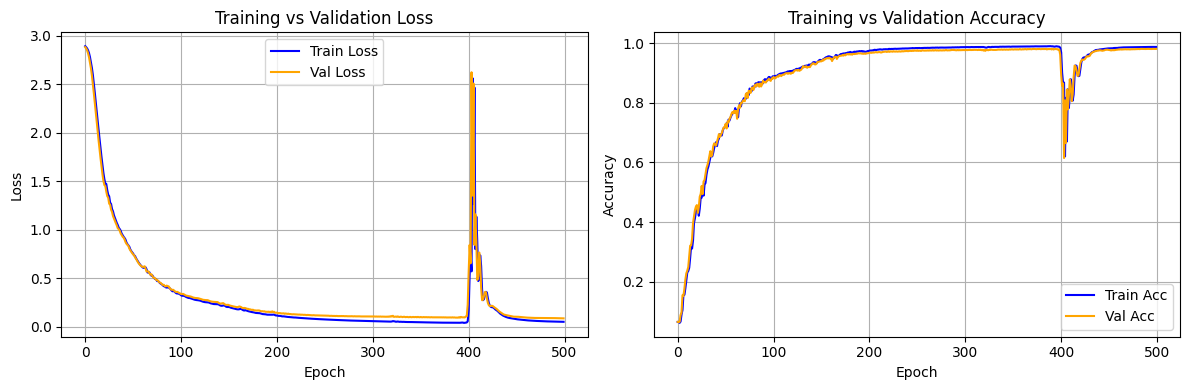

In [73]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Acc', color='blue')
axes[1].plot(history['val_acc'], label='Val Acc', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [74]:
with torch.no_grad():
  test_logits = model(X_test_tensor)
  pred_labels = torch.argmax(test_logits, dim=1)
  accuracy = (pred_labels == y_test_tensor).float().mean()
print("Test Accuracy", accuracy)

Test Accuracy tensor(0.9823)
